# Support Vector Machine e a Não Linearidade

Este notebook realiza uma análise de dados de projetos e utiliza técnicas de aprendizado de máquina para prever a conclusão dos projetos. As etapas incluem:

1. **Carregamento e preparação dos dados**: Importação dos dados de um arquivo CSV, limpeza e transformação dos dados.
2. **Divisão dos dados**: Separação dos dados em conjuntos de treino e teste.
3. **Treinamento do modelo**: Treinamento de um modelo de Máquina de Vetores de Suporte (SVM) para prever a conclusão dos projetos.
4. **Avaliação do modelo**: Avaliação da precisão do modelo utilizando o conjunto de teste.
5. **Visualização dos resultados**: Criação de gráficos para visualizar a performance do modelo e a distribuição dos dados.

In [10]:
import pandas as pd

dados = pd.read_csv('projects.csv', delimiter = ',')
dados['finalizado'] = dados['nao_finalizado'].map({ 1 : 0, 0: 1})
dados = dados.query("horas_esperadas > 0")
dados.head()


,nao_finalizado,horas_esperadas,preco,finalizado
0,0,75.0,6985.0,1
2,0,87.0,14205.0,1
3,1,13.0,100.0,0
4,0,2.0,202.0,1
5,0,49.0,1096.0,1


In [14]:
from sklearn.model_selection  import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

x = dados[["horas_esperadas", "preco"]]
y = dados["finalizado"]
 
SEED = 20

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, random_state = SEED, stratify = y)

print(f"Treinaremos com {len(treino_x)}")
print(f"Testaremos com {len(teste_x)}")

modelo = SVC(gamma = 'auto')
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurária foi de {acuracia: .2f}")

Treinaremos com 1617
Testaremos com 540
A acurária foi de  57.78


/Users/macieljunior/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


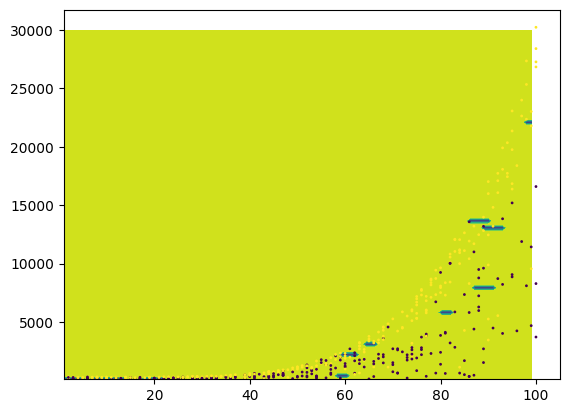

In [15]:
import numpy as np
import matplotlib.pyplot as plt

x_min = teste_x["horas_esperadas"].min()
x_max = teste_x["horas_esperadas"].max()
y_min = teste_x["preco"].min()
y_max = teste_x["preco"].max()

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels)

xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)


plt.contourf(xx, yy, Z)
plt.scatter(teste_x["horas_esperadas"], teste_x["preco"], c = teste_y, s = 1)

In [16]:
from sklearn.model_selection  import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

x = dados[["horas_esperadas", "preco"]]
y = dados["finalizado"]
 
SEED = 20

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state = SEED, stratify = y)

print(f"Treinaremos com {len(raw_treino_x)}")
print(f"Testaremos com {len(raw_teste_x)}")

scaler = StandardScaler()
scaler.fit(raw_treino_x)

treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

modelo = SVC(gamma = 'auto')
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurária foi de {acuracia: .2f}")

Treinaremos com 1617
Testaremos com 540
A acurária foi de  68.52


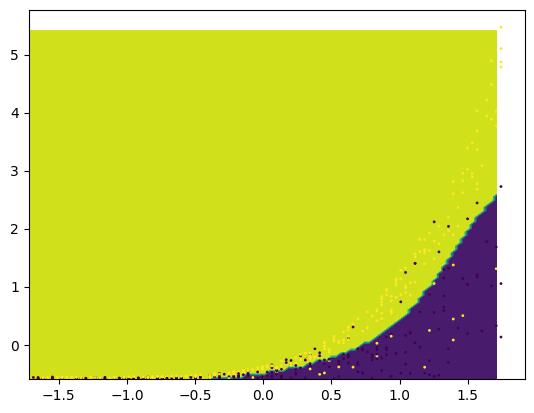

In [19]:
import numpy as np
import matplotlib.pyplot as plt

data_col1 = teste_x[:, 0]
data_col2 = teste_x[:, 1]


x_min = data_col1.min()
x_max = data_col1.max()
y_min = data_col2.min()
y_max = data_col2.max()

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min) / pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min) / pixels)

xx, yy = np.meshgrid(eixo_x, eixo_y)
pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)


plt.contourf(xx, yy, Z)
plt.scatter(data_col1, data_col2, c = teste_y, s = 1)